<!-- Cabeçalho -->
<br />
<p align="center">

  <h1 align="center">Perfil Estadual da População Indígena</h1>
  
</p>

## Introdução

O Estudo 4 aprofunda a análise dos Censos Demográficos de 2010 e 2022 na escala das 27 Unidades da Federação. Seu propósito não é reproduzir o perfil regional em 27 recortes isolados, mas investigar quanto a agregação por Grandes Regiões oculta diferenças internas de concentração, presença em Terras Indígenas, urbanização e crescimento demográfico.

A investigação exploratória foi inicialmente conduzida no Excel. Neste notebook, os indicadores selecionados são reproduzidos em pandas, validados e organizados de forma rastreável para sustentar as visualizações e interpretações finais.

## Objetivo e perguntas analíticas

A pergunta central deste estudo é:

> **Quanto a escala regional esconde da heterogeneidade existente entre as Unidades da Federação?**

Para respondê-la, serão examinadas cinco dimensões:

1. concentração da população indígena no Brasil e dentro de cada região;
2. relação entre o peso populacional da UF na região e a parcela de sua população residente em Terras Indígenas;
3. consistência estadual do padrão territorial identificado no Estudo 3;
4. diferenças entre crescimento absoluto e crescimento relativo;
5. mudanças na proporção de população indígena urbana entre 2010 e 2022.

Os resultados são descritivos. Variações entre os censos não serão interpretadas automaticamente como migração, deslocamento populacional ou relação causal.

In [24]:
from pathlib import Path

import numpy as np
import pandas as pd

from charts.state_profile import PlotPerfilEstadual

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda valor: f"{valor:.2f}")

## 1. Carregamento das bases processadas

In [25]:
# Considera tanto o diretório atual quanto seus diretórios-pai.
# Assim, o notebook funciona quando o kernel é iniciado na raiz do projeto
# ou dentro do próprio diretório do notebook.
diretorio_atual = Path.cwd().resolve()
ROOT = next(
    (
        caminho
        for caminho in (diretorio_atual, *diretorio_atual.parents)
        if (caminho / "pyproject.toml").exists()
    ),
    None,
)

if ROOT is None:
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto a partir do diretório atual."
    )

diretorio_tabelas = ROOT / "data" / "processed" / "table"
caminho_estados = diretorio_tabelas / "df_estados.csv"
caminho_regioes = diretorio_tabelas / "df_regioes.csv"

df_estados = pd.read_csv(caminho_estados)
df_regioes = pd.read_csv(caminho_regioes)

In [45]:
df_estados.head()

,Localidade,Indígenas 2010 Total,Indígenas 2010 Urbano,Indígenas 2010 Rural,Indígenas 2010 TI Total,Indígenas 2010 TI Urbano,Indígenas 2010 TI Rural,Indígenas 2010 Fora TI Total,Indígenas 2010 Fora TI Urbano,Indígenas 2010 Fora TI Rural,Indígenas 2022 Total,Indígenas 2022 Urbano,Indígenas 2022 Rural,Indígenas 2022 TI Total,Indígenas 2022 TI Urbano,Indígenas 2022 TI Rural,Indígenas 2022 Fora TI Total,Indígenas 2022 Fora TI Urbano,Indígenas 2022 Fora TI Rural,% Indígenas 2010 Urbano,% Indígenas 2010 Rural,% Indígenas 2010 TI Urbano,% Indígenas 2010 TI Rural,% Indígenas 2010 Fora TI Urbano,% Indígenas 2010 Fora TI Rural,% Indígenas 2022 Urbano,% Indígenas 2022 Rural,% Indígenas 2022 TI Urbano,% Indígenas 2022 TI Rural,% Indígenas 2022 Fora TI Urbano,% Indígenas 2022 Fora TI Rural
0,Rondônia,13076,2906,10170,9217,0,9217,3859,2906,953,21146,8094,13052,11525,0,11525,9621,8094,1527,22.22,77.78,0.00,100.00,75.30,24.70,38.28,61.72,0.00,100.00,84.13,15.87
1,Acre,17578,2595,14983,13308,0,13308,4270,2595,1675,31694,8849,22845,19583,0,19583,12111,8849,3262,14.76,85.24,0.00,100.00,60.77,39.23,27.92,72.08,0.00,100.00,73.07,26.93
2,Amazonas,183514,34316,149198,129529,1230,128299,53985,33086,20899,490935,305866,185069,149080,33070,116010,341855,272796,69059,18.70,81.30,0.95,99.05,61.29,38.71,62.30,37.70,22.18,77.82,79.80,20.20
3,Roraima,55922,8243,47679,46505,949,45556,9417,7294,2123,97668,21674,75994,71754,1544,70210,25914,20130,5784,14.74,85.26,2.04,97.96,77.46,22.54,22.19,77.81,2.15,97.85,77.68,22.32
4,Pará,51217,9966,41251,35816,0,35816,15401,9966,5435,80980,25338,55642,41819,360,41459,39161,24978,14183,19.46,80.54,0.00,100.00,64.71,35.29,31.29,68.71,0.86,99.14,63.78,36.22


## 2. Preparação dos indicadores estaduais

A base estadual é enriquecida com a região de cada UF e com os indicadores derivados utilizados neste estudo. É essencial distinguir os denominadores:

$$\text{Participação na Região (\%)} = \frac{\text{População indígena da UF}}{\text{População indígena da região}} \times 100$$

$$\text{Indígenas em TI (\%)} = \frac{\text{População indígena da UF em TI}}{\text{População indígena total da UF}} \times 100$$

O primeiro indicador mede o peso da UF em sua região. O segundo descreve a distribuição territorial da população indígena dentro da própria UF. Consequentemente, eles não constituem partes de um mesmo total e não devem ser somados.

In [27]:
ufs_por_regiao = {
    "Norte": (
        "Rondônia", "Acre", "Amazonas", "Roraima",
        "Pará", "Amapá", "Tocantins",
    ),
    "Nordeste": (
        "Maranhão", "Piauí", "Ceará", "Rio Grande do Norte",
        "Paraíba", "Pernambuco", "Alagoas", "Sergipe", "Bahia",
    ),
    "Centro-Oeste": (
        "Mato Grosso do Sul", "Mato Grosso", "Goiás", "Distrito Federal",
    ),
    "Sudeste": (
        "Minas Gerais", "Espírito Santo", "Rio de Janeiro", "São Paulo",
    ),
    "Sul": (
        "Paraná", "Santa Catarina", "Rio Grande do Sul",
    ),
}

mapa_uf_regiao = {
    uf: regiao
    for regiao, unidades_federacao in ufs_por_regiao.items()
    for uf in unidades_federacao
}

ordem_regioes = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]

df_perfil = df_estados.copy()
df_perfil["Região"] = df_perfil["Localidade"].map(mapa_uf_regiao)
df_perfil["Região"] = pd.Categorical(
    df_perfil["Região"],
    categories=ordem_regioes,
    ordered=True,
)

In [28]:
graficos_estaduais = PlotPerfilEstadual(
    df=df_perfil,
    diretorio_saida=ROOT / "outputs" / "figures" / "charts",
)

In [29]:
total_brasil_2022 = df_perfil["Indígenas 2022 Total"].sum()
total_regiao_2022 = df_perfil.groupby(
    "Região", observed=True
)["Indígenas 2022 Total"].transform("sum")

df_perfil["Participação no Brasil (%)"] = (
    df_perfil["Indígenas 2022 Total"].div(total_brasil_2022).mul(100)
)

df_perfil["Participação na Região (%)"] = (
    df_perfil["Indígenas 2022 Total"].div(total_regiao_2022).mul(100)
)

df_perfil["% Indígenas 2022 em TI"] = (
    df_perfil["Indígenas 2022 TI Total"]
    .div(df_perfil["Indígenas 2022 Total"])
    .mul(100)
)

df_perfil["Urbanização 2010 (%)"] = (
    df_perfil["Indígenas 2010 Urbano"]
    .div(df_perfil["Indígenas 2010 Total"])
    .mul(100)
)

df_perfil["Urbanização 2022 (%)"] = (
    df_perfil["Indígenas 2022 Urbano"]
    .div(df_perfil["Indígenas 2022 Total"])
    .mul(100)
)

df_perfil["Mudança na urbanização (p.p.)"] = (
    df_perfil["Urbanização 2022 (%)"]
    - df_perfil["Urbanização 2010 (%)"]
)

df_perfil["Crescimento absoluto"] = (
    df_perfil["Indígenas 2022 Total"]
    - df_perfil["Indígenas 2010 Total"]
)

df_perfil["Crescimento relativo (%)"] = (
    df_perfil["Crescimento absoluto"]
    .div(df_perfil["Indígenas 2010 Total"])
    .mul(100)
)

df_perfil["TI urbano (%)"] = np.where(
    df_perfil["Indígenas 2022 TI Total"].gt(0),
    (
        df_perfil["Indígenas 2022 TI Urbano"]
        .div(df_perfil["Indígenas 2022 TI Total"])
        .mul(100)
    ),
    np.nan,
)

df_perfil["Fora TI urbano (%)"] = (
    df_perfil["Indígenas 2022 Fora TI Urbano"]
    .div(df_perfil["Indígenas 2022 Fora TI Total"])
    .mul(100)
)

## 3. Validação da base analítica

As verificações seguintes garantem que a inclusão da dimensão regional e o cálculo dos indicadores preservaram a integridade da base.

In [30]:
totais_regionais_calculados = (
    df_perfil.groupby("Região", observed=True)["Indígenas 2022 Total"]
    .sum()
    .sort_index()
)

totais_regionais_referencia = (
    df_regioes.set_index("Localidade")["Indígenas 2022 Total"]
    .reindex(ordem_regioes)
)

validacoes = pd.Series(
    {
        "A base contém as 27 UFs": len(df_perfil) == 27,
        "Todas as UFs receberam uma região": df_perfil["Região"].notna().all(),
        "Não existem UFs duplicadas": not df_perfil["Localidade"].duplicated().any(),
        "Total = urbano + rural em 2022": (
            df_perfil["Indígenas 2022 Total"]
            == df_perfil["Indígenas 2022 Urbano"]
            + df_perfil["Indígenas 2022 Rural"]
        ).all(),
        "Total = em TI + fora de TI em 2022": (
            df_perfil["Indígenas 2022 Total"]
            == df_perfil["Indígenas 2022 TI Total"]
            + df_perfil["Indígenas 2022 Fora TI Total"]
        ).all(),
        "Participações nacionais somam 100%": np.isclose(
            df_perfil["Participação no Brasil (%)"].sum(), 100
        ),
        "Participações estaduais somam 100% em cada região": (
            df_perfil.groupby("Região", observed=True)[
                "Participação na Região (%)"
            ]
            .sum()
            .sub(100)
            .abs()
            .lt(1e-9)
            .all()
        ),
        "Agregação estadual coincide com a base regional": (
            totais_regionais_calculados.to_numpy()
            == totais_regionais_referencia.to_numpy()
        ).all(),
    },
    name="Resultado",
)

falhas = validacoes.index[~validacoes].tolist()

if falhas:
    raise ValueError(f"Falha nas validações da base: {falhas}")

validacoes.map({True: "Aprovada", False: "Reprovada"}).to_frame()

,Resultado
A base contém as 27 UFs,Aprovada
Todas as UFs receberam uma região,Aprovada
Não existem UFs duplicadas,Aprovada
Total = urbano + rural em 2022,Aprovada
Total = em TI + fora de TI em 2022,Aprovada
Participações nacionais somam 100%,Aprovada
Participações estaduais somam 100% em cada região,Aprovada
Agregação estadual coincide com a base regional,Aprovada


## 4. A população indígena está distribuída de forma equilibrada entre as UFs?

A participação nacional identifica quais UFs concentram o maior contingente indígena do país. A participação regional permite verificar se o perfil agregado de uma região é amplamente compartilhado entre seus estados ou fortemente influenciado por uma única UF.

In [31]:
ranking_nacional = (
    df_perfil[
        ["Localidade", "Região", "Indígenas 2022 Total", "Participação no Brasil (%)"]
    ]
    .sort_values("Participação no Brasil (%)", ascending=False)
    .reset_index(drop=True)
)

participacao_tres_maiores = ranking_nacional.head(3)[
    "Participação no Brasil (%)"
].sum()

ranking_nacional.head(10)

,Localidade,Região,Indígenas 2022 Total,Participação no Brasil (%)
0,Amazonas,Norte,490935,28.97
1,Bahia,Nordeste,229443,13.54
2,Mato Grosso do Sul,Centro-Oeste,116469,6.87
3,Pernambuco,Nordeste,106646,6.29
4,Roraima,Norte,97668,5.76
5,Pará,Norte,80980,4.78
6,Mato Grosso,Centro-Oeste,58356,3.44
7,Maranhão,Nordeste,57166,3.37
8,Ceará,Nordeste,56372,3.33
9,São Paulo,Sudeste,55331,3.26


In [32]:
lideres_regionais = (
    df_perfil[
        ["Região", "Localidade", "Indígenas 2022 Total", "Participação na Região (%)"]
    ]
    .sort_values(
        ["Região", "Participação na Região (%)"],
        ascending=[True, False],
    )
    .groupby("Região", observed=True, as_index=False)
    .head(1)
    .reset_index(drop=True)
)

lideres_regionais

,Região,Localidade,Indígenas 2022 Total,Participação na Região (%)
0,Norte,Amazonas,490935,65.13
1,Nordeste,Bahia,229443,43.36
2,Centro-Oeste,Mato Grosso do Sul,116469,58.19
3,Sudeste,São Paulo,55331,44.83
4,Sul,Rio Grande do Sul,36102,40.87


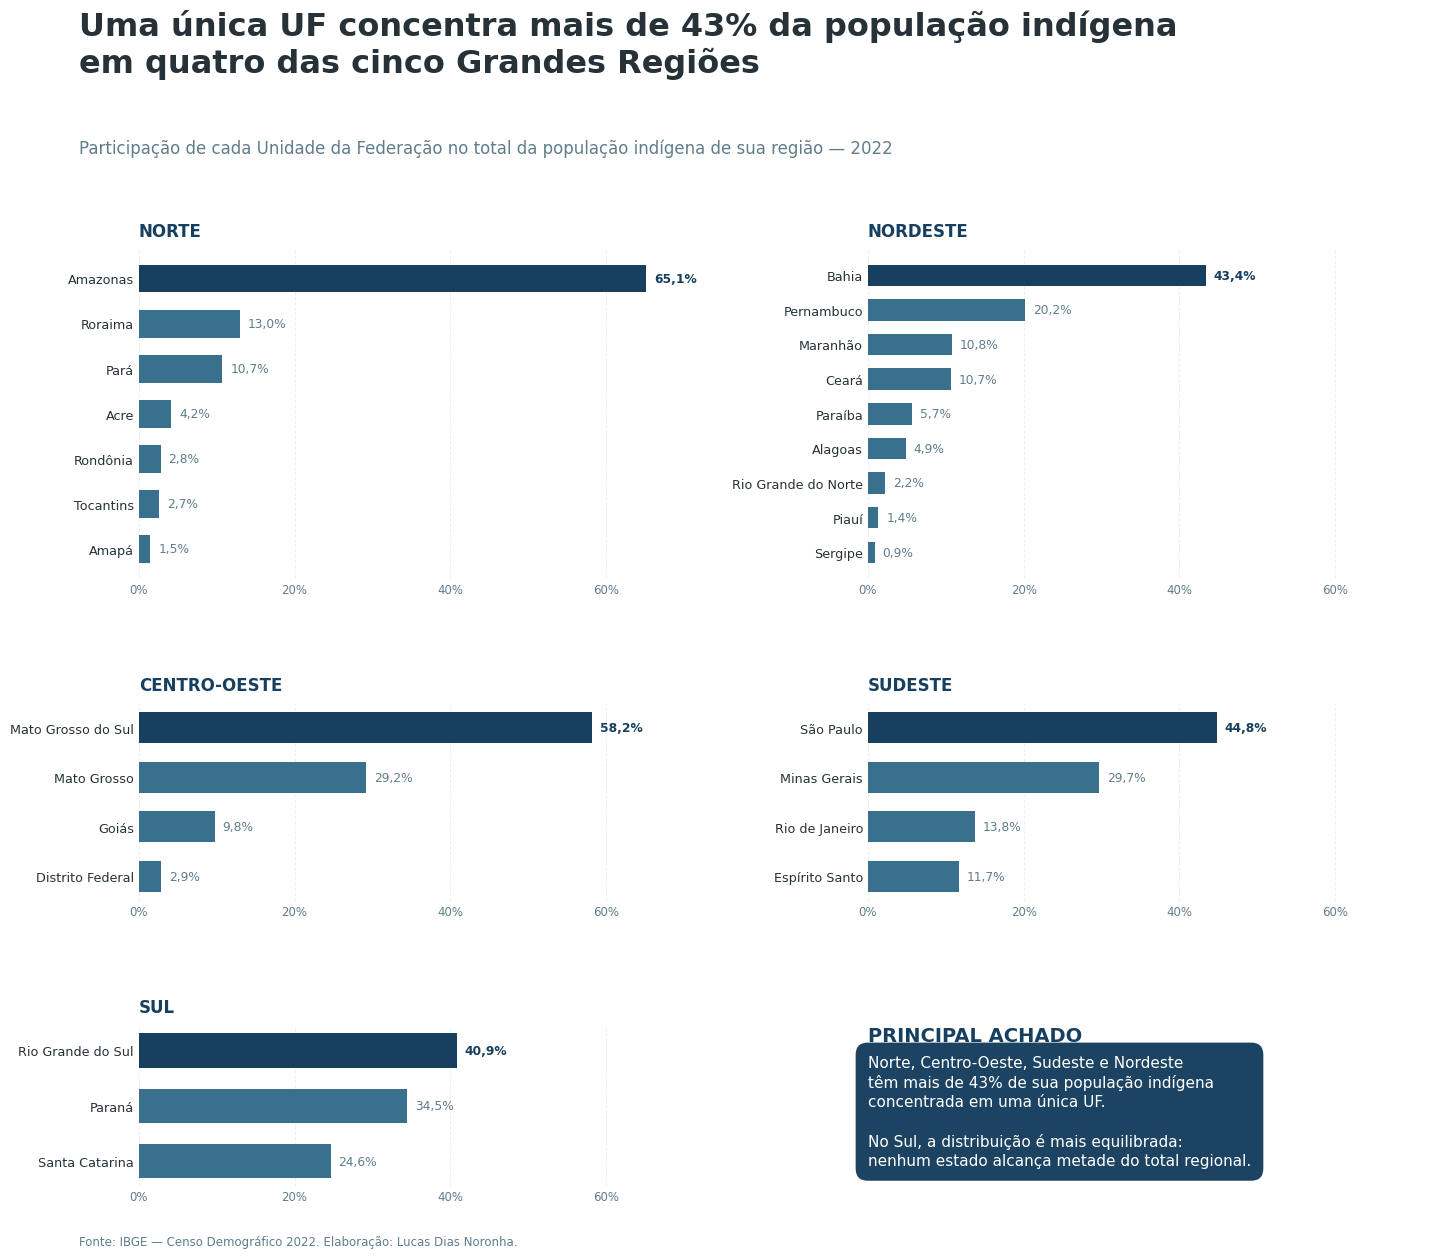

PosixPath('/home/lucas/workspace/pessoal/exploracao-dados-indigenas-2010-2022/outputs/figures/charts/grafico_concentracao_intrarregional_2022.png')

In [33]:
graficos_estaduais.plot_concentracao_intrarregional()


### Resposta

A distribuição estadual é fortemente concentrada. Amazonas, Bahia e Mato Grosso do Sul reúnem aproximadamente **49,4%** da população indígena brasileira registrada na base. A concentração também aparece dentro das regiões: Amazonas representa **65,1%** do total do Norte, Mato Grosso do Sul, **58,2%** do Centro-Oeste, e Bahia, **43,4%** do Nordeste.

O Sul apresenta a composição mais equilibrada: Rio Grande do Sul, Paraná e Santa Catarina respondem, respectivamente, por **40,9%**, **34,5%** e **24,6%** da população indígena regional. Portanto, a interpretação de um resultado regional exige considerar quanto cada UF contribui para sua formação.

## 5. Uma UF com grande peso regional também possui alta proporção de população em Terras Indígenas?

O confronto entre participação regional e presença em Terras Indígenas permite distinguir duas dimensões que podem parecer semelhantes, mas respondem a perguntas diferentes: a magnitude populacional da UF na região e a distribuição territorial de sua própria população indígena.

In [34]:
referencia_ti_regional = (
    df_perfil.groupby("Região", observed=True, as_index=False)
    .agg(
        populacao_total=("Indígenas 2022 Total", "sum"),
        populacao_em_ti=("Indígenas 2022 TI Total", "sum"),
    )
)

referencia_ti_regional["% Indígenas em TI na região"] = (
    referencia_ti_regional["populacao_em_ti"]
    .div(referencia_ti_regional["populacao_total"])
    .mul(100)
)

mapa_referencia_ti = referencia_ti_regional.set_index("Região")[
    "% Indígenas em TI na região"
].to_dict()

df_perfil["Referência regional em TI (%)"] = (
    df_perfil["Região"].astype(str).map(mapa_referencia_ti)
)
df_perfil["Diferença da referência regional em TI (p.p.)"] = (
    df_perfil["% Indígenas 2022 em TI"]
    - df_perfil["Referência regional em TI (%)"]
)

referencia_ti_regional

,Região,populacao_total,populacao_em_ti,% Indígenas em TI na região
0,Norte,753780,316827,42.03
1,Nordeste,529128,129882,24.55
2,Centro-Oeste,200153,114201,57.06
3,Sudeste,123434,21525,17.44
4,Sul,88341,40409,45.74


In [35]:
contrastes_peso_ti = (
    df_perfil[
        [
            "Região",
            "Localidade",
            "Participação na Região (%)",
            "% Indígenas 2022 em TI",
            "Referência regional em TI (%)",
            "Diferença da referência regional em TI (p.p.)",
        ]
    ]
    .sort_values(
        ["Região", "Participação na Região (%)"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

contrastes_peso_ti

,Região,Localidade,Participação na Região (%),% Indígenas 2022 em TI,Referência regional em TI (%),Diferença da referência regional em TI (p.p.)
0,Norte,Amazonas,65.13,30.37,42.03,-11.67
1,Norte,Roraima,12.96,73.47,42.03,31.44
2,Norte,Pará,10.74,51.64,42.03,9.61
3,Norte,Acre,4.20,61.79,42.03,19.76
4,Norte,Rondônia,2.81,54.50,42.03,12.47
5,Norte,Tocantins,2.66,75.98,42.03,33.95
6,Norte,Amapá,1.50,69.29,42.03,27.26
7,Nordeste,Bahia,43.36,7.50,24.55,-17.05
8,Nordeste,Pernambuco,20.16,32.18,24.55,7.63
9,Nordeste,Maranhão,10.80,72.91,24.55,48.36


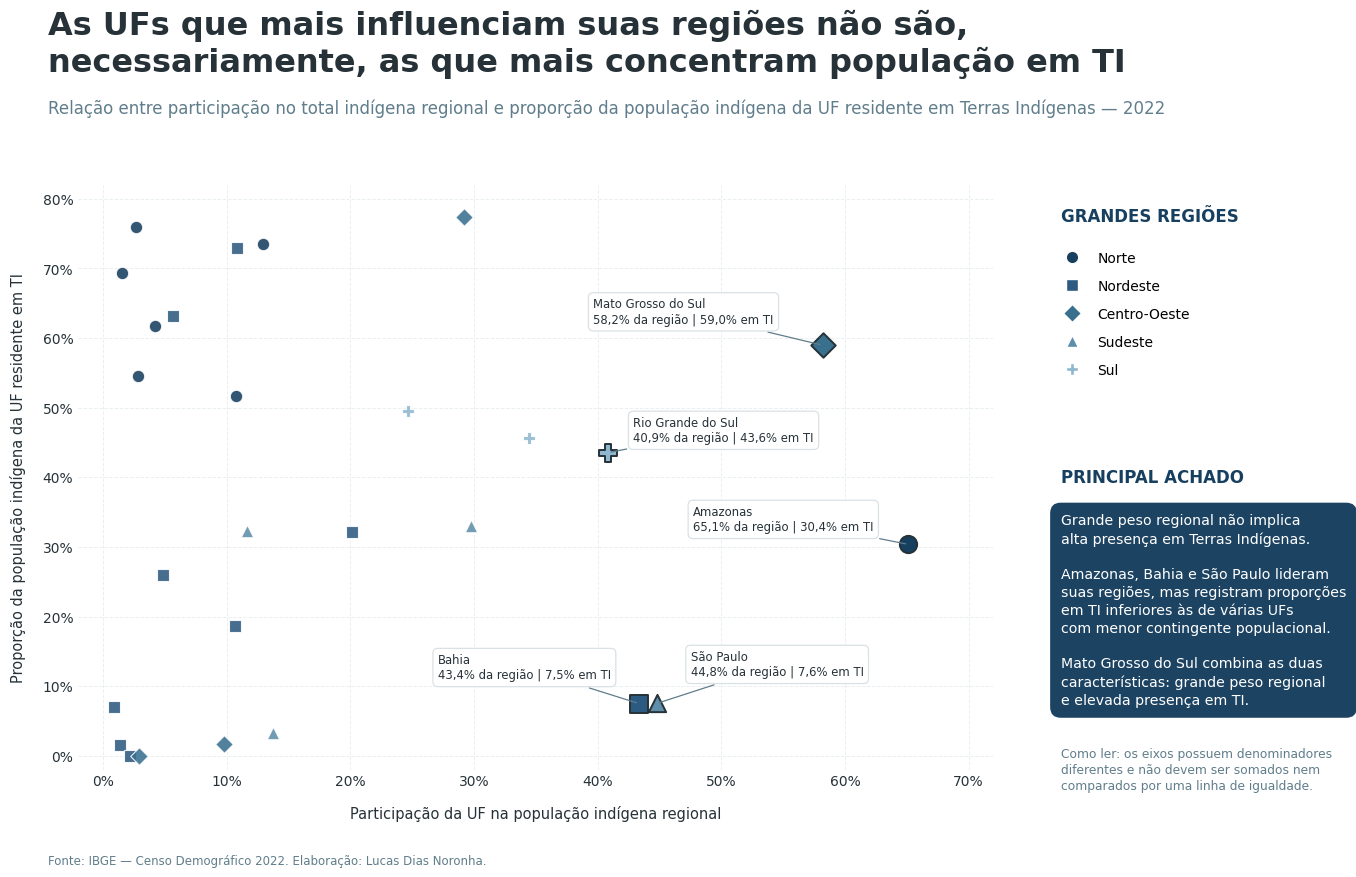

PosixPath('/home/lucas/workspace/pessoal/exploracao-dados-indigenas-2010-2022/outputs/figures/charts/grafico_peso_regional_presenca_ti_2022.png')

In [36]:
graficos_estaduais.plot_peso_regional_vs_presenca_ti()

### Resposta

Grande peso populacional e alta presença relativa em Terras Indígenas não são equivalentes. O Amazonas concentra **65,1%** da população indígena do Norte, mas **30,4%** de sua população indígena reside em Terras Indígenas, proporção inferior aos **42,0%** observados no agregado regional. A Bahia responde por **43,4%** do Nordeste, embora somente **7,5%** de sua população indígena esteja em Terras Indígenas. Em São Paulo, a relação é semelhante: a UF concentra **44,8%** do Sudeste e registra **7,5%** de população indígena em TI.

Mato Grosso do Sul constitui um caso distinto: além de representar **58,2%** do Centro-Oeste, possui **59,0%** de sua população indígena em Terras Indígenas, valor próximo à proporção regional agregada de **57,1%**. Esses contrastes demonstram que a escala regional combina estruturas estaduais substancialmente diferentes.

## 6. O padrão territorial do Estudo 3 permanece consistente nas UFs?

O Estudo 3 identificou predominância rural dentro de Terras Indígenas e predominância urbana fora delas em todas as Grandes Regiões. A escala estadual permite testar se essa regularidade resulta de um comportamento compartilhado pelas UFs ou se encobre exceções internas.

In [37]:
df_perfil["Perfil em TI"] = np.select(
    [
        df_perfil["Indígenas 2022 TI Total"].eq(0),
        df_perfil["Indígenas 2022 TI Urbano"].gt(
            df_perfil["Indígenas 2022 TI Rural"]
        ),
        df_perfil["Indígenas 2022 TI Rural"].gt(
            df_perfil["Indígenas 2022 TI Urbano"]
        ),
    ],
    ["Sem população em TI", "Predominância urbana", "Predominância rural"],
    default="Equilíbrio",
)

df_perfil["Perfil fora de TI"] = np.select(
    [
        df_perfil["Indígenas 2022 Fora TI Urbano"].gt(
            df_perfil["Indígenas 2022 Fora TI Rural"]
        ),
        df_perfil["Indígenas 2022 Fora TI Rural"].gt(
            df_perfil["Indígenas 2022 Fora TI Urbano"]
        ),
    ],
    ["Predominância urbana", "Predominância rural"],
    default="Equilíbrio",
)

excecoes_contexto = df_perfil.loc[
    (
        df_perfil["Indígenas 2022 TI Total"].gt(0)
        & df_perfil["Perfil em TI"].ne("Predominância rural")
    )
    | df_perfil["Perfil fora de TI"].ne("Predominância urbana")
    | df_perfil["Indígenas 2022 TI Total"].eq(0),
    [
        "Localidade",
        "Região",
        "Indígenas 2022 TI Total",
        "TI urbano (%)",
        "Perfil em TI",
        "Fora TI urbano (%)",
        "Perfil fora de TI",
    ],
].reset_index(drop=True)

excecoes_contexto

,Localidade,Região,Indígenas 2022 TI Total,TI urbano (%),Perfil em TI,Fora TI urbano (%),Perfil fora de TI
0,Ceará,Nordeste,10521,62.18,Predominância urbana,60.84,Predominância urbana
1,Rio Grande do Norte,Nordeste,0,NaN,Sem população em TI,45.97,Predominância rural
2,Distrito Federal,Centro-Oeste,0,NaN,Sem população em TI,91.84,Predominância urbana


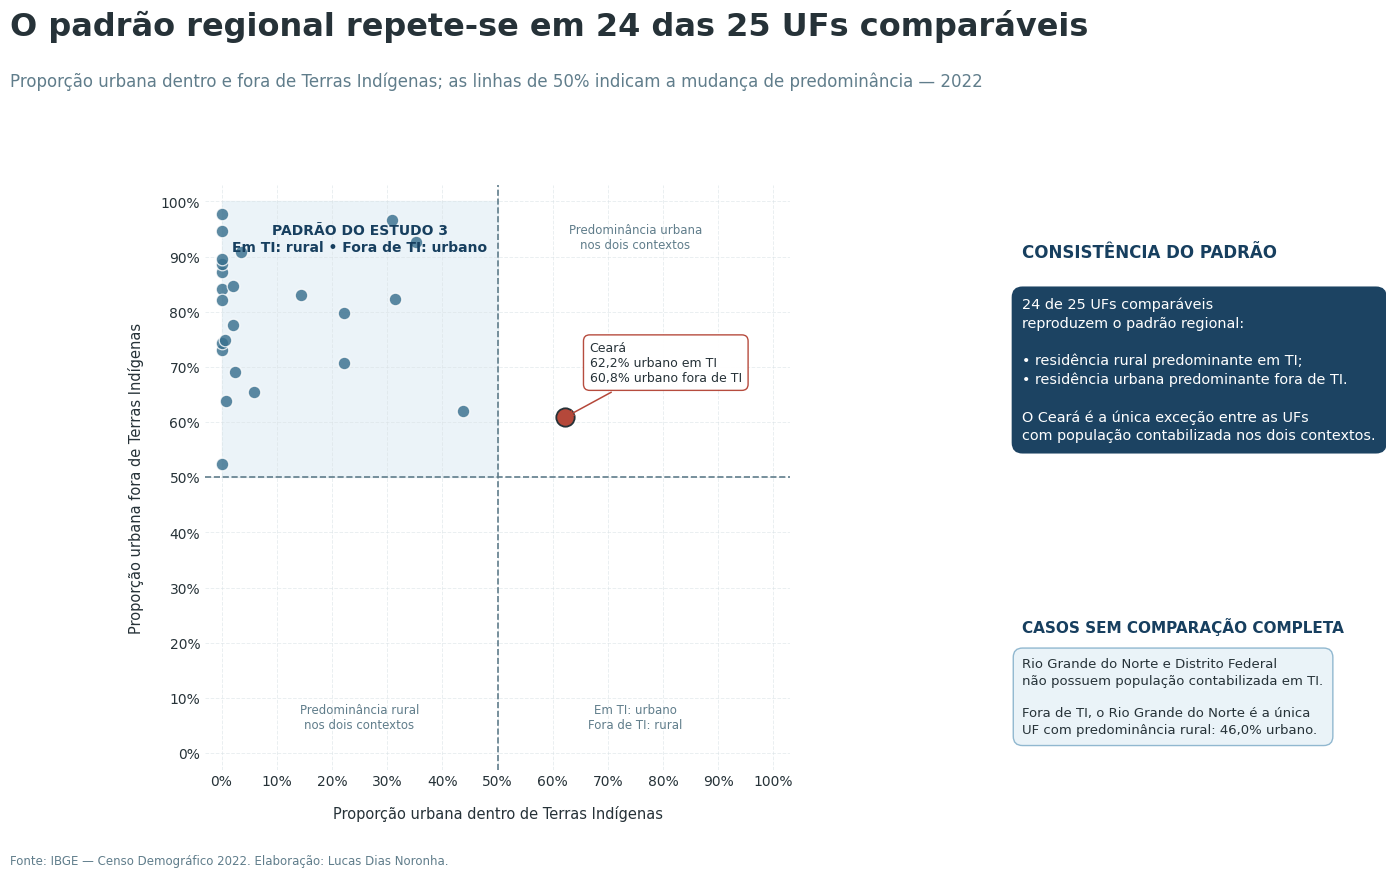

PosixPath('/home/lucas/workspace/pessoal/exploracao-dados-indigenas-2010-2022/outputs/figures/charts/grafico_padrao_territorial_estadual_2022.png')

In [38]:
graficos_estaduais.plot_padrao_territorial_estadual()

### Resposta

O padrão regional permanece amplamente consistente no nível estadual. Entre as 25 UFs com população contabilizada em Terras Indígenas, somente o **Ceará** apresenta predominância urbana dentro desses territórios, com **62,2%**. Fora de Terras Indígenas, somente o **Rio Grande do Norte** apresenta predominância rural, pois a proporção urbana é de **46,0%**.

Rio Grande do Norte e Distrito Federal não possuem população registrada em Terras Indígenas na base de 2022; portanto, não se deve calcular nem interpretar a composição urbano-rural dentro de TI para essas UFs. A existência de poucas exceções não invalida o padrão regional, mas revela situações estaduais que a agregação não permite observar.

## 7. Quais UFs mais cresceram em termos absolutos e relativos?

O crescimento absoluto mede quantas pessoas foram acrescentadas ao contingente registrado. O crescimento relativo mede essa variação em relação ao valor inicial de 2010. Os dois indicadores são complementares e podem produzir rankings muito diferentes.

$$\text{Crescimento relativo (\%)} = \frac{\text{Total}_{2022} - \text{Total}_{2010}}{\text{Total}_{2010}} \times 100$$

In [39]:
colunas_crescimento = [
    "Localidade",
    "Região",
    "Indígenas 2010 Total",
    "Indígenas 2022 Total",
    "Crescimento absoluto",
    "Crescimento relativo (%)",
]

ranking_crescimento_absoluto = (
    df_perfil[colunas_crescimento]
    .sort_values("Crescimento absoluto", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

ranking_crescimento_relativo = (
    df_perfil[colunas_crescimento]
    .sort_values("Crescimento relativo (%)", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

comparacao_rankings_crescimento = pd.concat(
    {
        "Maiores crescimentos absolutos": ranking_crescimento_absoluto,
        "Maiores crescimentos relativos": ranking_crescimento_relativo,
    },
    names=["Critério", "Posição"],
)

comparacao_rankings_crescimento

Localidade        Região  \
Critério                       Posição                                      
Maiores crescimentos absolutos 0                   Amazonas         Norte   
                               1                      Bahia      Nordeste   
                               2                 Pernambuco      Nordeste   
                               3                    Roraima         Norte   
                               4         Mato Grosso do Sul  Centro-Oeste   
                               5                      Ceará      Nordeste   
                               6                       Pará         Norte   
                               7                   Maranhão      Nordeste   
                               8                       Acre         Norte   
                               9                  São Paulo       Sudeste   
Maiores crescimentos relativos 0        Rio Grande do Norte      Nordeste   
                               1                      Bahia      Nordeste   
                               2                      Ceará      Nordeste   
                               3                   Amazonas         Norte   
                               4                      Piauí      Nordeste   
                               5                      Goiás  Centro-Oeste   
                               6                       Acre         Norte   
                               7                 Pernambuco      Nordeste   
                               8                    Roraima         Norte   
                               9                   Rondônia         Norte   

                                        Indígenas 2010 Total  \
Critério                       Posição                         
Maiores crescimentos absolutos 0                      183514   
                               1                       60120   
                               2                       60995   
                               3                       55922   
                               4                       77025   
                               5                       20697   
                               6                       51217   
                               7                       38831   
                               8                       17578   
                               9                       41981   
Maiores crescimentos relativos 0                        2597   
                               1                       60120   
                               2                       20697   
                               3                      183514   
                               4                        2944   
                               5                        8583   
                               6                       17578   
                               7                       60995   
                               8                       55922   
                               9                       13076   

                                        Indígenas 2022 Total  \
Critério                       Posição                         
Maiores crescimentos absolutos 0                      490935   
                               1                      229443   
                               2                      106646   
                               3                       97668   
                               4                      116469   
                               5                       56372   
                               6                       80980   
                               7                       57166   
                               8                       31694   
                               9                       55331   
Maiores crescimentos relativos 0                       11724   
                               1                      229443   
                               2                 

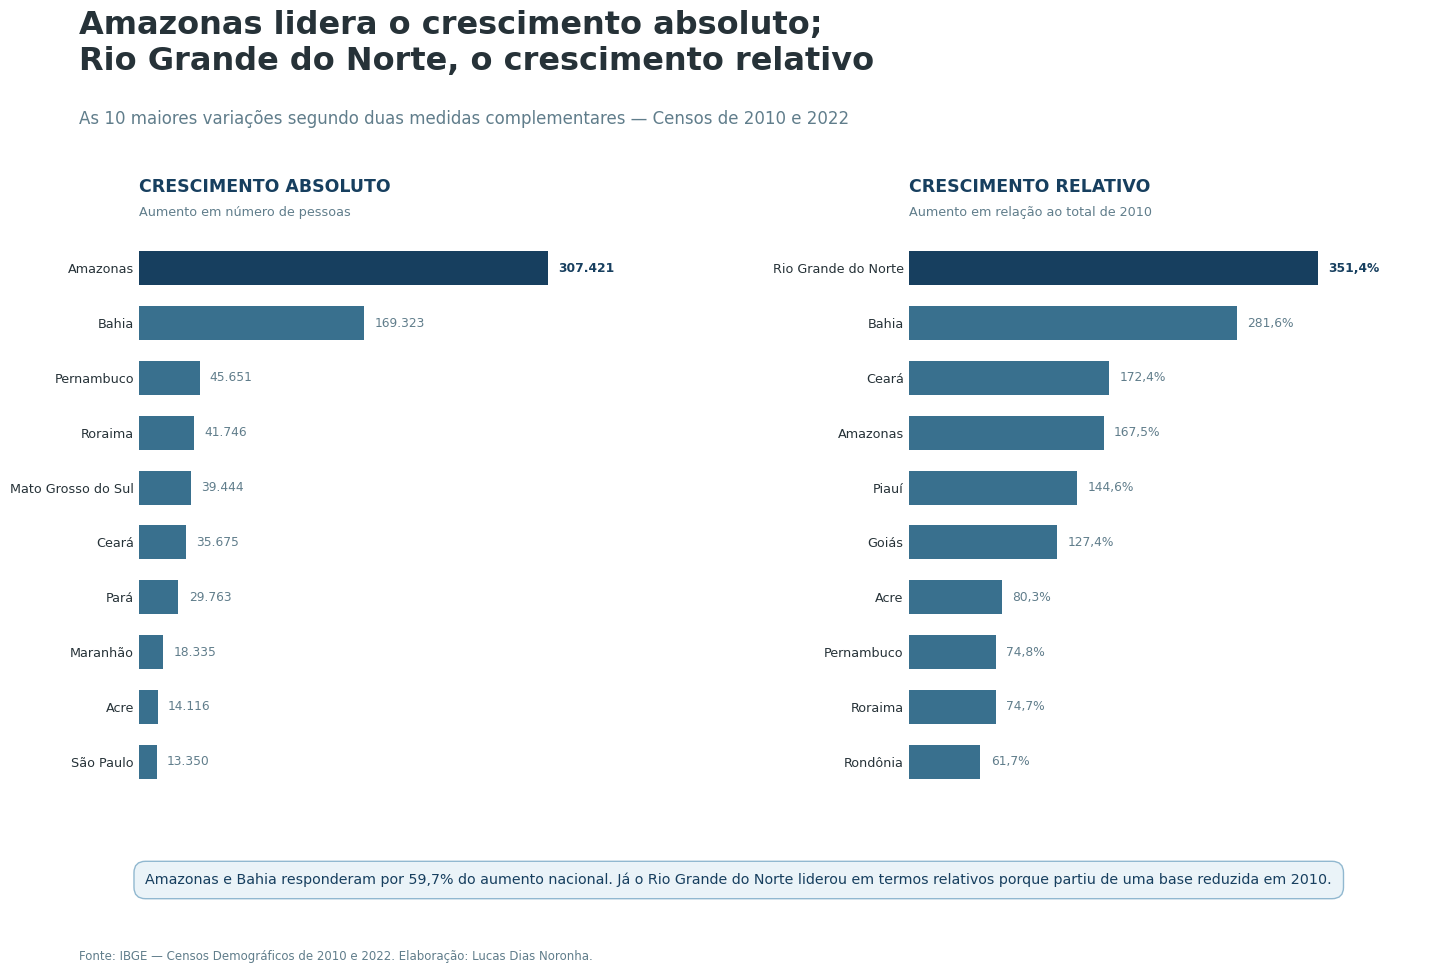

PosixPath('/home/lucas/workspace/pessoal/exploracao-dados-indigenas-2010-2022/outputs/figures/charts/grafico_crescimento_estadual_absoluto_relativo.png')

In [40]:
graficos_estaduais.plot_crescimento_absoluto_relativo()

### Resposta

Amazonas e Bahia registraram os maiores crescimentos absolutos: **307.421** e **169.323** pessoas, respectivamente. Juntos, os dois estados responderam por aproximadamente **59,7%** do aumento nacional observado entre os censos.

O ranking relativo apresenta outra perspectiva. O Rio Grande do Norte cresceu **351,4%**, a maior variação proporcional, mas partiu de uma base de somente 2.597 pessoas em 2010 e teve aumento absoluto de 9.127. O contraste demonstra por que percentuais elevados não devem ser interpretados sem considerar o tamanho inicial da população.

## 8. Como mudou a proporção de população indígena urbana entre 2010 e 2022?

A mudança de urbanização é expressa em pontos percentuais, pois compara duas proporções calculadas sobre os respectivos totais de 2010 e 2022.

$$\Delta\text{ urbanização (p.p.)} = \text{Urbanização}_{2022} - \text{Urbanização}_{2010}$$

In [41]:
mudanca_urbanizacao = (
    df_perfil[
        [
            "Localidade",
            "Região",
            "Urbanização 2010 (%)",
            "Urbanização 2022 (%)",
            "Mudança na urbanização (p.p.)",
        ]
    ]
    .sort_values("Mudança na urbanização (p.p.)", ascending=False)
    .reset_index(drop=True)
)

mudanca_urbanizacao

,Localidade,Região,Urbanização 2010 (%),Urbanização 2022 (%),Mudança na urbanização (p.p.)
0,Amazonas,Norte,18.70,62.30,43.60
1,Alagoas,Nordeste,38.26,57.24,18.98
2,Mato Grosso do Sul,Centro-Oeste,19.34,35.94,16.61
3,Rondônia,Norte,22.22,38.28,16.05
4,Bahia,Nordeste,63.30,78.47,15.16
5,Acre,Norte,14.76,27.92,13.16
6,Pará,Norte,19.46,31.29,11.83
7,Pernambuco,Nordeste,45.12,55.10,9.98
8,Roraima,Norte,14.74,22.19,7.45
9,Amapá,Norte,18.35,25.22,6.87


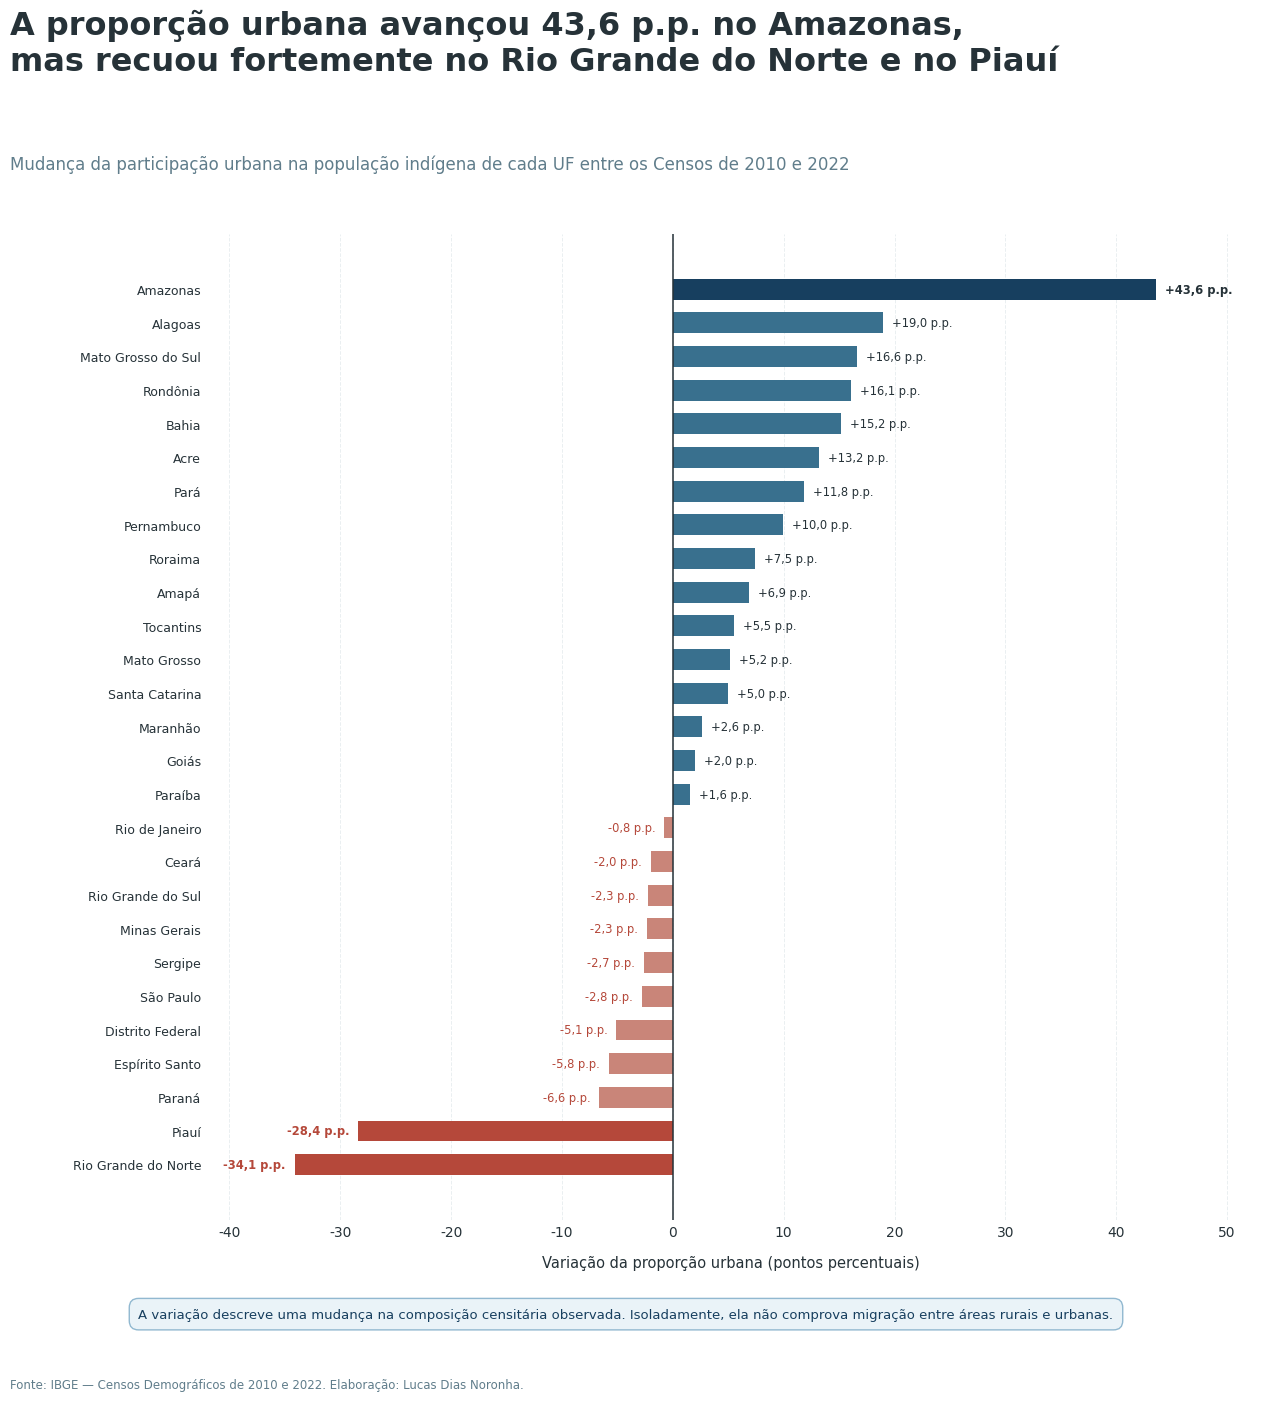

PosixPath('/home/lucas/workspace/pessoal/exploracao-dados-indigenas-2010-2022/outputs/figures/charts/grafico_mudanca_urbanizacao_estadual_2010_2022.png')

In [42]:
graficos_estaduais.plot_mudanca_urbanizacao()

### Resposta

O Amazonas apresentou a maior elevação da proporção urbana, passando de **18,7%** para **62,3%**, uma mudança de **43,6 pontos percentuais**. Em sentido oposto, Rio Grande do Norte e Piauí registraram reduções de **34,1** e **28,4 pontos percentuais**, respectivamente.

Essas diferenças descrevem mudanças na composição censitária observada, mas não permitem concluir, isoladamente, que houve migração ou deslocamento físico entre áreas rurais e urbanas. Mudanças metodológicas, cobertura censitária e processos de identificação também devem ser considerados na interpretação.

## Síntese analítica

A escala estadual revela que os resultados regionais são produzidos por combinações internas muito desiguais. Em quatro das cinco regiões, uma única UF concentra mais de 40% da população indígena regional; no Norte e no Centro-Oeste, essa participação supera 58%. Ao mesmo tempo, o peso regional de uma UF não determina a parcela de sua população residente em Terras Indígenas.

Apesar da heterogeneidade de magnitude, presença em TI, urbanização e crescimento, o padrão territorial identificado no Estudo 3 permanece altamente consistente entre as UFs: predomina a residência rural dentro de Terras Indígenas e a residência urbana fora delas, com poucas exceções estaduais.

## 9. Exportação da base analítica estadual

A base enriquecida é salva na camada de dados processados para que os módulos de visualização utilizem exatamente os indicadores validados neste notebook.

In [43]:
caminho_saida = diretorio_tabelas / "df_state_profile.csv"

df_perfil.to_csv(
    caminho_saida,
    index=False,
    encoding="utf-8",
)

caminho_saida

PosixPath('/home/lucas/workspace/pessoal/exploracao-dados-indigenas-2010-2022/data/processed/table/df_state_profile.csv')

## Informações sobre a base analítica

In [44]:
df_perfil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 46 columns):
 #   Column                                         Non-Null Count  Dtype   
---  ------                                         --------------  -----   
 0   Localidade                                     27 non-null     object  
 1   Indígenas 2010 Total                           27 non-null     int64   
 2   Indígenas 2010 Urbano                          27 non-null     int64   
 3   Indígenas 2010 Rural                           27 non-null     int64   
 4   Indígenas 2010 TI Total                        27 non-null     int64   
 5   Indígenas 2010 TI Urbano                       27 non-null     int64   
 6   Indígenas 2010 TI Rural                        27 non-null     int64   
 7   Indígenas 2010 Fora TI Total                   27 non-null     int64   
 8   Indígenas 2010 Fora TI Urbano                  27 non-null     int64   
 9   Indígenas 2010 Fora TI Rural                 